<a href="https://colab.research.google.com/github/toluenensama/2025Advent-of-code/blob/main/notebooks/python_interface/psi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%bash
set -euo pipefail

MAMBA_ROOT="$HOME/mamba"
MAMBA_BIN="$MAMBA_ROOT/bin/micromamba"
if [ ! -x "$MAMBA_BIN" ]; then
  mkdir -p "$MAMBA_ROOT"
  curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj -C "$MAMBA_ROOT" bin/micromamba >/dev/null
fi

"$MAMBA_BIN" create -y -r "$MAMBA_ROOT" -n psi4 -c conda-forge psi4 python=3.12 >/dev/null

In [5]:
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# STUDENTS SHOULD IGNORE THESE LINES
%%bash
set -euo pipefail
MAMBA_ROOT="$HOME/mamba"
MAMBA_BIN="$MAMBA_ROOT/bin/micromamba"
cat > psi4.in <<'EOF'
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>


# Your input file should go in this middle section
# Write this as a classic-style Psi4 input file (not a Python script)

molecule {
  F 0.0 0.0 0.0
  F 1.1 0.0 0.0
}

set {
  basis aug-cc-pVDZ
  reference uhf
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 1.2 0.0 0.0
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 1.3 0.0 0.0
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 1.4 0.0 0.0
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 1.5 0.0 0.0
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 1.6 0.0 0.0
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 1.7 0.0 0.0
}

energy('CCSD(T)')

molecule {
  F 0.0 0.0 0.0
  F 2.0 0.0 0.0
}

molecule {
  F 0.0 0.0 0.0
  F 2.5 0.0 0.0
}

energy('CCSD(T)')

energy('CCSD(T)')


# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
# STUDENTS SHOULD IGNORE THESE LINES
EOF
"$MAMBA_BIN" run -r "$MAMBA_ROOT" -n psi4 psi4 psi4.in psi4.out
cat psi4.out
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>



    -----------------------------------------------------------------------
          Psi4: An Open-Source Ab Initio Electronic Structure Package
                               Psi4 1.10 release

                         Git: Rev {} zzzzzzz 


    D. G. A. Smith, L. A. Burns, A. C. Simmonett, R. M. Parrish,
    M. C. Schieber, R. Galvelis, P. Kraus, H. Kruse, R. Di Remigio,
    A. Alenaizan, A. M. James, S. Lehtola, J. P. Misiewicz, M. Scheurer,
    R. A. Shaw, J. B. Schriber, Y. Xie, Z. L. Glick, D. A. Sirianni,
    J. S. O'Brien, J. M. Waldrop, A. Kumar, E. G. Hohenstein,
    B. P. Pritchard, B. R. Brooks, H. F. Schaefer III, A. Yu. Sokolov,
    K. Patkowski, A. E. DePrince III, U. Bozkaya, R. A. King,
    F. A. Evangelista, J. M. Turney, T. D. Crawford, C. D. Sherrill,
    J. Chem. Phys. 152(18) 184108 (2020). https://doi.org/10.1063/5.0006002

                            Additional Code Authors
    E. T. Seidl, C. L. Janssen, E. F. Valeev, M. L. Leininger,
    J. F. Gonthier, R. M

In [8]:
import re
import numpy as np
# Read the content of psi4.out file
with open('psi4.out', 'r') as f:
    psi4_output_content = f.read()

ccsd_t_energies = []
# Regex to find lines containing 'CCSD(T) total energy' and capture the floating-point number
pattern = re.compile(r'CCSD\(T\) total energy\s+=\s+(-?\d+\.\d+)')

for line in psi4_output_content.splitlines():
    match = pattern.search(line)
    if match:
        ccsd_t_energies.append(float(match.group(1)))


energy_arr = []
print("Extracted CCSD(T) total energies:")
for energy in ccsd_t_energies:
    energy_arr.append(energy)

num_energy = np.array(energy_arr)

Extracted CCSD(T) total energies:


In [9]:
num_energy

array([-199.0204222 , -199.10061756, -199.13751897, -199.15054277,
       -199.15079727, -199.14492754, -199.136941  , -199.11918786,
       -199.11918786])

In [12]:
dis_arr = np.array([1.1,1.2,1.3,1.4,1.5,1.6,1.7,2.0,2.5])

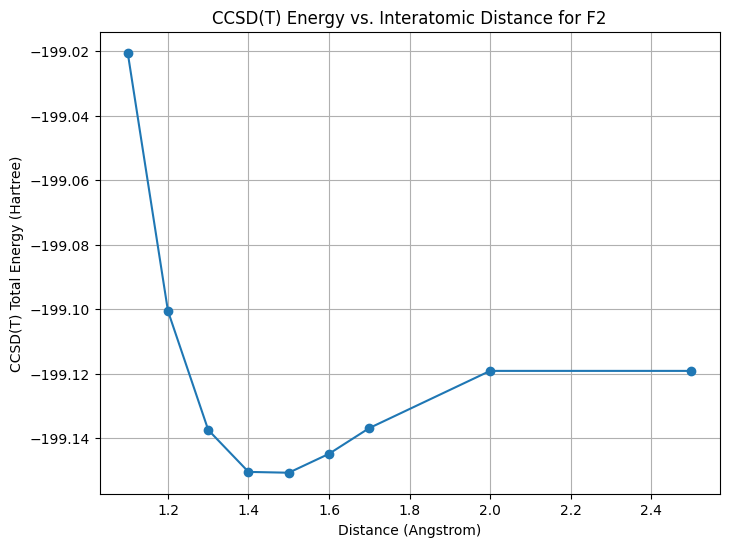

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(dis_arr, num_energy, marker='o', linestyle='-')
plt.xlabel('Distance (Angstrom)')
plt.ylabel('CCSD(T) Total Energy (Hartree)')
plt.title('CCSD(T) Energy vs. Interatomic Distance for F2')
plt.grid(True)
plt.show()